<a href="https://colab.research.google.com/github/meryymarta/DataMining/blob/main/Week8_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Age  Credit_amount  Duration  Employment_since      Purpose
0   25           2000        12                 2          car
1   40           7000        48                 5     business
2   35           3500        24                 4          car
3   23           1200        10                 1    furniture
4   52           9000        60                 5  real_estate


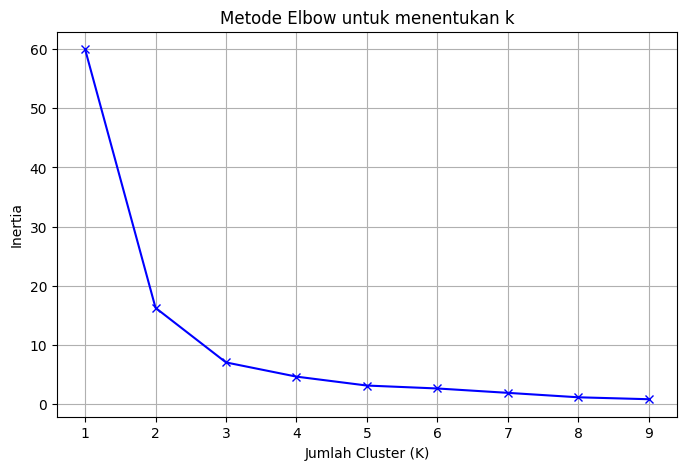

   Age  Credit_amount  Duration  Employment_since      Purpose  Cluster
0   25           2000        12                 2          car        2
1   40           7000        48                 5     business        0
2   35           3500        24                 4          car        1
3   23           1200        10                 1    furniture        2
4   52           9000        60                 5  real_estate        0


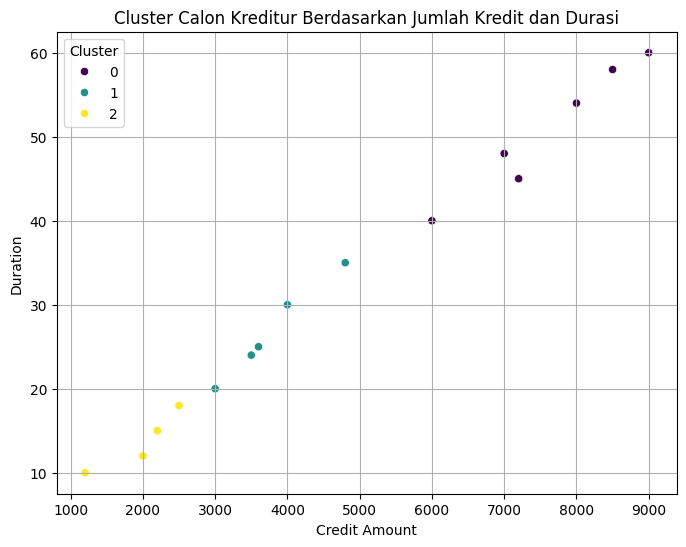


Silhoutte Score: 0.549
Inertia (k=3): 7.016


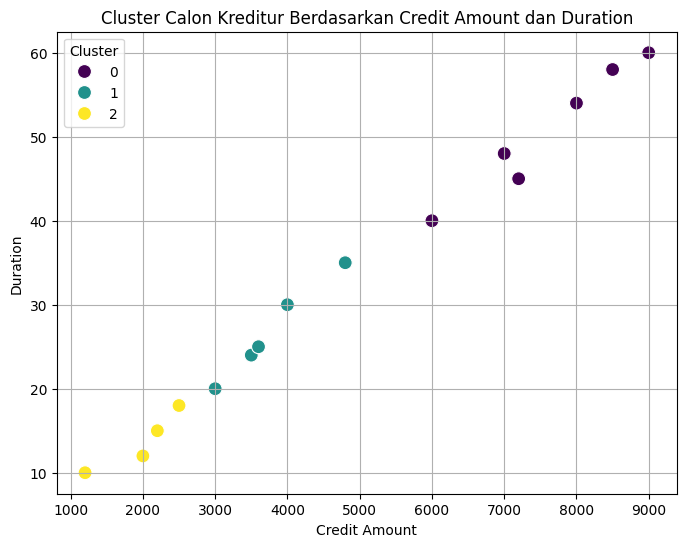

In [14]:
# TUGAS MINGGU 10 -- CLUSTERING

#Klasterisasi data Resiko Kredit calon nasabah
#import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

#Load data
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/kuliah/credit_data_sample.csv', sep=';')

print(df.head())

#Memilih fitur clustering (saat ini hanya yang numerik)
features = ['Age', 'Credit_amount', 'Duration', 'Employment_since']
X = df[features]

#Standarisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Menentukan jumlah cluster menggunakan Elbow Method
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

#Plot hasil elbow
plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.title('Metode Elbow untuk menentukan k')
plt.grid(True)
plt.show()

#Melakukan K-Means Clustering 3 Cluster
#Membuat model KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

#Lihat hsil clustering
print (df.head())

#Visualisasi hasil cluster
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Credit_amount'],
y=df['Duration'], hue=df['Cluster'],
palette='viridis')
plt.title('Cluster Calon Kreditur Berdasarkan Jumlah Kredit dan Durasi')
plt.xlabel('Credit Amount')
plt.ylabel('Duration')
plt.grid(True)
plt.show()

#Performa dari K-Means model menggunakan Silhoutte Score
#a. Hiung Silhoutte Score
silhoutte_avg = silhouette_score(X_scaled, df['Cluster'])
print(f"\nSilhoutte Score: {silhoutte_avg:.3f}")

#b. Tampilkan Inertia Akhir
print(f"Inertia (k=3): {kmeans.inertia_:.3f}")

#Visualisasi hasil clustering (2 fitur: Credit Amount vs Duration)
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Credit_amount'],
    y=df['Duration'],
    hue=df['Cluster'],
    palette='viridis',
    s=100
)

plt.title('Cluster Calon Kreditur Berdasarkan Credit Amount dan Duration')
plt.xlabel('Credit Amount')
plt.ylabel('Duration')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()



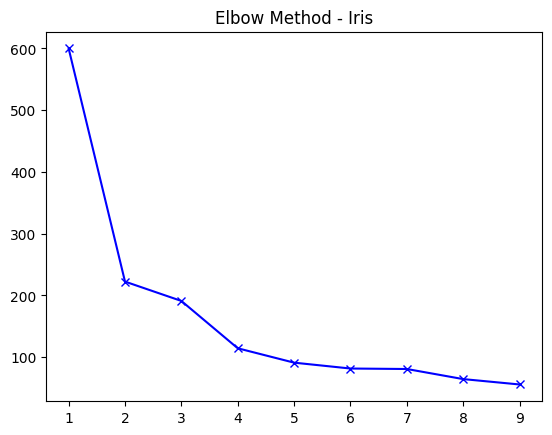

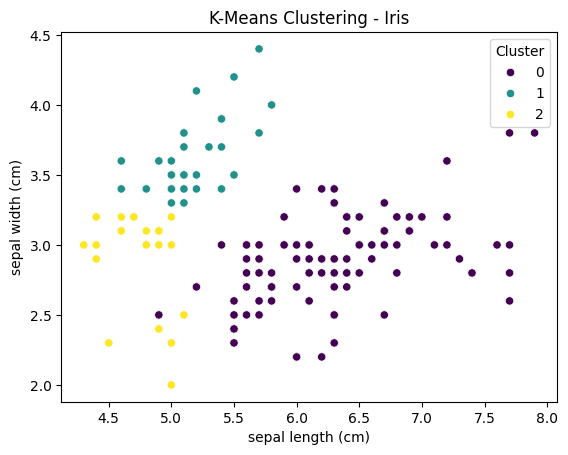

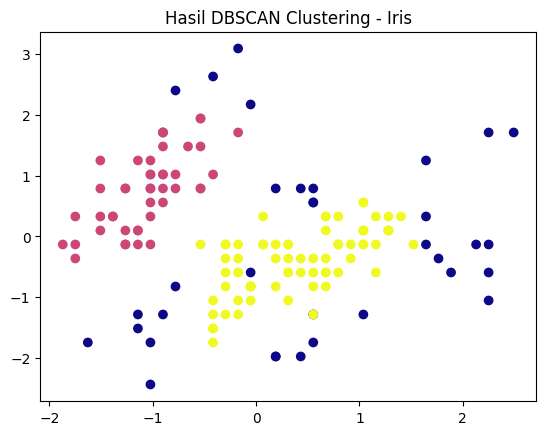

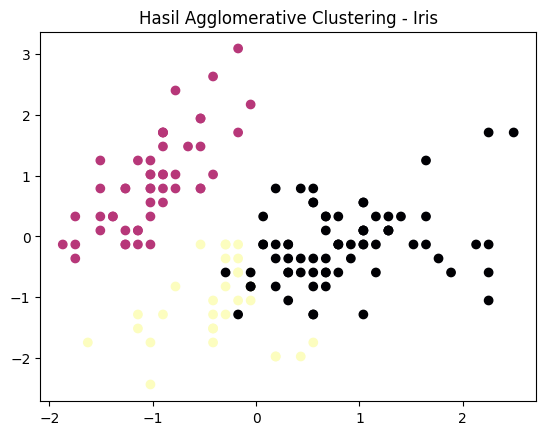

In [17]:
#TUGAS
#CLUSTERING DATA IRIS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

#Load data Iris
iris = load_iris()
df_iris = pd.DataFrame(data=iris.data, columns=iris.feature_names)

#Standarisasi
scaler = StandardScaler()
iris_scaled = scaler.fit_transform(df_iris)

#Elbow method untuk Iris
inertia_iris = []
K = range(1, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(iris_scaled)
    inertia_iris.append(km.inertia_)
plt.plot(K, inertia_iris, 'bx-')
plt.title('Elbow Method - Iris')
plt.show()

#Fit KMeans (K=3 karena ada 3 spesies iris)
kmeans_iris = KMeans(n_clusters=3, random_state=42)
df_iris['Cluster'] = kmeans_iris.fit_predict(iris_scaled)

#Visualisasi
sns.scatterplot(x=df_iris.iloc[:, 0], y=df_iris.iloc[:, 1], hue=df_iris['Cluster'], palette='viridis')
plt.title('K-Means Clustering - Iris')
plt.show()

#Menggunakan data iris_scaled dari langkah sebelumnya
#jarak maksimum antar dua sampel, min_samples: jumlah sampel minimal untuk jadi pusat
dbscan_iris = DBSCAN(eps=0.5, min_samples=5)
iris_labels_db = dbscan_iris.fit_predict(iris_scaled)

# Visualisasi
plt.scatter(iris_scaled[:, 0], iris_scaled[:, 1], c=iris_labels_db, cmap='plasma')
plt.title("Hasil DBSCAN Clustering - Iris")
plt.show()

#Menggunakan Agglomerative Clustering
agg_iris = AgglomerativeClustering(n_clusters=3)
iris_labels_agg = agg_iris.fit_predict(iris_scaled)

#Visualisasi
plt.scatter(iris_scaled[:, 0], iris_scaled[:, 1], c=iris_labels_agg, cmap='magma')
plt.title("Hasil Agglomerative Clustering - Iris")
plt.show()


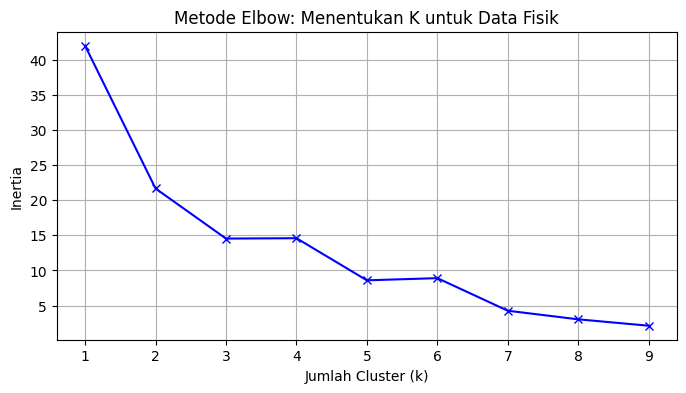

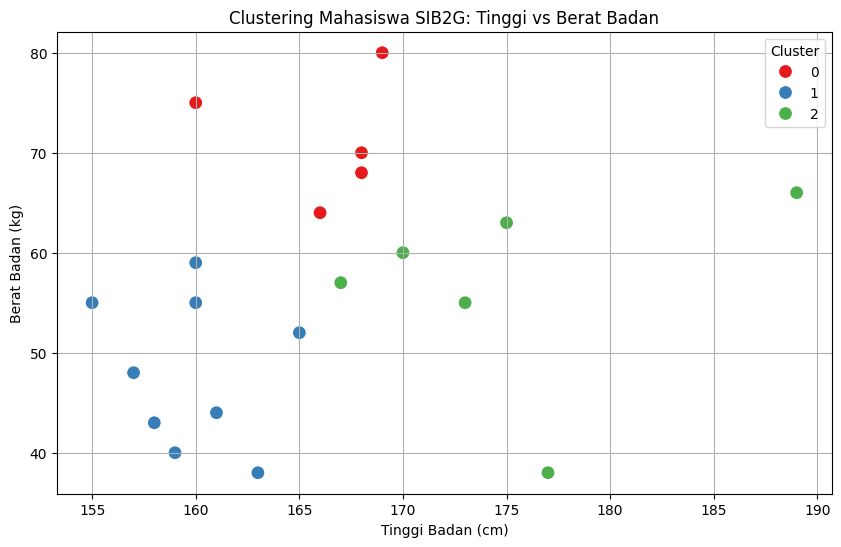


--- Analisa Karakteristik Fisik per Cluster ---
             Height  Weight
Cluster                    
0        166.200000    71.4
1        159.500000    48.2
2        175.166667    56.5


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#Load Data
df_kelas = pd.read_csv('Dataset SIB2G - Sheet1.csv')

#Pembersihan Data
def clean_number(x):
    if pd.isna(x): return np.nan
    try:
        s = str(x).strip()
        if ',' in s and '.' in s:
            s = s.replace('.', '').replace(',', '.')
        else:
            s = s.replace(',', '.')
        return float(s)
    except:
        return np.nan

df_kelas['Height'] = df_kelas['Height'].apply(clean_number)
df_kelas['Weight'] = df_kelas['Weight'].apply(clean_number)

#Fitur yang digunakan
features = ['Height', 'Weight']
df_clean = df_kelas.dropna(subset=features).copy()

#Standarisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[features])

#Metode Elbow
inertia = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

#Visualisasi Elbow
plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Metode Elbow: Menentukan K untuk Data Fisik')
plt.grid(True)
plt.show()

#Eksekusi K-Means
# Berdasarkan Elbow, kita pilih k=3
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, n_init='auto', random_state=42)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

#Visualisasi Scatter Plot: Tinggi vs Berat
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Height', y='Weight',
                hue='Cluster', palette='Set1', s=100)
plt.title('Clustering Mahasiswa SIB2G: Tinggi vs Berat Badan')
plt.xlabel('Tinggi Badan (cm)')
plt.ylabel('Berat Badan (kg)')
plt.grid(True)
plt.show()

#Tampilkan Analisa Rata-rata per Cluster
print("\n--- Analisa Karakteristik Fisik per Cluster ---")
print(df_clean.groupby('Cluster')[features].mean())